# Pnomotoraks Tespiti icin U-Net + SAM2 + VLM Pipeline (v3)

Bu notebook su asamalari icerir:
1. Ham CT_goruntuler_anon verisinden hasta bazli, sizinti olmayan train/val/test veri hazirligi (16-bit maske -> ikili 8-bit maske, goruntu hic kucultulmeden orijinal cozunurlukte 224x224 parcalara/patch'lere bolunur)
2. U-Net (MobileNetV2 encoder) egitimi - val seti model secimi icin, test seti sadece sonuc raporlamasi icin
3. SAM2 ile segmentasyon sinir iyilestirmesi ve test seti degerlendirmesi (SAM2 ciktisi U-Net ile yeterince ortusmuyorsa guvenilmez sayilir)
4. Acik kaynakli bir VLM (Qwen2-VL) ile otomatik radyolojik raporlama

Calistirmadan once: anonimlestirilmis `CT_goruntuler_anon` klasorunu Google Drive'iniza yukleyin ve asagidaki `RAW_DIR` yolunu buna gore ayarlayin. Orijinal (isim iceren) `CT_goruntuler` klasorunu bulut ortamina yuklemeyin.

**v3 notlari (v2'deki dusuk Dice/IoU sonuclarindan sonra yapilan degisiklikler):** v2'de tum goruntu 224x224'e kucultuluyordu (resize); bu, ince pnomotoraks/plevral hat gibi kucuk yapilarin kaybolmasina yol acabiliyordu ve toplam veri miktari da azdi (852 goruntu). v3'te goruntu kucultulmez, bunun yerine orijinal cozunurlukten 224x224 boyutunda parcalar (patch) kesilir; bu hem cozunurluk kaybini onler hem de egitim ornegi sayisini onemli olcude artirir. SAM2 birlestirmesine de bir IoU esigi eklendi: SAM2 ciktisi U-Net ile yeterince ortusmuyorsa (ince ayar yapilmadigi icin boyle olabiliyor) sonuc U-Net maskesine geri duser, boylece SAM2 sonuclari kotulestirmez.

In [2]:
!pip install -q segmentation_models_pytorch albumentations opencv-python-headless pillow scipy matplotlib gradio pandas
!pip install -q 'transformers>=4.46.0' accelerate qwen-vl-utils bitsandbytes
!rm -rf /content/sam2
!git clone -q https://github.com/facebookresearch/sam2.git /content/sam2
%cd /content/sam2
!SAM2_BUILD_CUDA=0 pip install -q -e '.[notebooks]'
!mkdir -p checkpoints
!wget -q -O /content/sam2/checkpoints/sam2.1_hiera_small.pt https://dl.fbaipublicfiles.com/segment_anything_2/092824/sam2.1_hiera_small.pt
%cd /content

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.9/40.9 MB 22.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.5/35.5 MB 21.1 MB/s eta 0:00:00
/content/sam2
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 2.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.6/13.6 MB 58.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.8/155.8 kB 16.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 99.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.9/65.9 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 915.3/915.3 kB 63.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━

## 1. Veri Hazirlama

Hasta bazli bolme uygulanir: bir hastanin hicbir kesiti birden fazla kumede (train/val/test) yer almaz. Maskeler orijinalde 16-bit etiket haritasidir (0=arka plan, 1=pnomotoraks, 2=ciger). Ikili pnomotoraks hedefi icin sadece deger 1 pozitif kabul edilir.

In [3]:
import os, glob, random, csv
import numpy as np
import cv2
import torch
import torch.nn as nn
from PIL import Image
from scipy import ndimage
from torch.utils.data import Dataset, DataLoader
import segmentation_models_pytorch as smp
import albumentations as A
from albumentations.pytorch import ToTensorV2
import matplotlib.pyplot as plt
import pandas as pd

from google.colab import drive
drive.mount('/content/drive')

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Cihaz:', DEVICE)

RAW_DIR = '/content/drive/MyDrive/CT_goruntuler_anon'
# Parcalar Drive yerine yerel Colab diskine yazilir. Drive'a bagli klasorden
# binlerce kucuk dosyayi her epoch'ta tekrar tekrar okumak (FUSE baglantisi
# uzerinden) egitimi ciddi sekilde yavaslatiyordu. Yerel disk oturum kapaninca
# silinir, bu yuzden nihai model agirligi ve manifest ayrica Drive'a kopyalanir.
PROCESSED_DIR = '/content/pnomotoraks_processed_v3_patches'
DRIVE_BACKUP_DIR = '/content/drive/MyDrive/pnomotoraks_v3_artifacts'
os.makedirs(DRIVE_BACKUP_DIR, exist_ok=True)

IMAGE_SIZE = 224
PATCH_STRIDE = 224
SEED = 42
PNEUMOTHORAX_LABEL = 1
TRAIN_RATIO = 0.65
VAL_RATIO = 0.10
EVAL_SAMPLE_SIZE = 300  # SAM2 degerlendirmesi bu kadar rastgele ornek uzerinden yapilir (SAM2 yavas oldugu icin)

random.seed(SEED)
np.random.seed(SEED)

Mounted at /content/drive
Cihaz: cuda


In [4]:
def find_pairs_for_patient(patient_dir):
    pairs = []
    jpg_files = sorted(glob.glob(os.path.join(patient_dir, '*.jpg')))
    for jpg_path in jpg_files:
        stem = os.path.splitext(os.path.basename(jpg_path))[0]
        png_path = os.path.join(patient_dir, stem + '.png')
        if os.path.exists(png_path):
            pairs.append((jpg_path, png_path))
    return pairs


def load_binary_mask_8bit(mask_path, pneumothorax_label=PNEUMOTHORAX_LABEL):
    mask_raw = np.array(Image.open(mask_path))
    if mask_raw.ndim == 3:
        mask_raw = mask_raw[..., 0]
    binary = (mask_raw == pneumothorax_label).astype(np.uint8) * 255
    return binary


def load_image_rgb(image_path):
    image = cv2.imread(image_path, cv2.IMREAD_COLOR)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    return image


def extract_patches(image_rgb, mask_8bit, patch_size=IMAGE_SIZE, stride=PATCH_STRIDE):
    # Goruntuyu hic kucultmeden, orijinal cozunurlukte patch_size x patch_size
    # parcalara boler. Tum goruntu kaplanacak sekilde son satir/sutun sinira hizalanir.
    h, w = mask_8bit.shape[:2]

    if h <= patch_size:
        ys = [0]
    else:
        ys = sorted(set(list(range(0, h - patch_size, stride)) + [h - patch_size]))

    if w <= patch_size:
        xs = [0]
    else:
        xs = sorted(set(list(range(0, w - patch_size, stride)) + [w - patch_size]))

    patches = []
    for y in ys:
        for x in xs:
            img_patch = image_rgb[y:y + patch_size, x:x + patch_size]
            mask_patch = mask_8bit[y:y + patch_size, x:x + patch_size]

            pad_h = patch_size - img_patch.shape[0]
            pad_w = patch_size - img_patch.shape[1]
            if pad_h > 0 or pad_w > 0:
                img_patch = cv2.copyMakeBorder(img_patch, 0, pad_h, 0, pad_w, cv2.BORDER_CONSTANT, value=0)
                mask_patch = cv2.copyMakeBorder(mask_patch, 0, pad_h, 0, pad_w, cv2.BORDER_CONSTANT, value=0)

            patches.append((x, y, img_patch, mask_patch))
    return patches

In [5]:
patient_dirs = sorted([d for d in glob.glob(os.path.join(RAW_DIR, '*')) if os.path.isdir(d)])
patient_index = {}
for pdir in patient_dirs:
    patient_id = os.path.basename(pdir)
    pairs = find_pairs_for_patient(pdir)
    if len(pairs) > 0:
        patient_index[patient_id] = pairs

total_pairs = sum(len(v) for v in patient_index.values())
print(f'Hasta sayisi: {len(patient_index)}')
print(f'Toplam goruntu-maske cifti: {total_pairs}')

patient_ids = sorted(patient_index.keys())
rng = random.Random(SEED)
rng.shuffle(patient_ids)

n = len(patient_ids)
n_train = int(round(n * TRAIN_RATIO))
n_val = int(round(n * VAL_RATIO))

train_ids = set(patient_ids[:n_train])
val_ids = set(patient_ids[n_train:n_train + n_val])
test_ids = set(patient_ids[n_train + n_val:])

assert train_ids.isdisjoint(val_ids)
assert train_ids.isdisjoint(test_ids)
assert val_ids.isdisjoint(test_ids)
print(f'Train hasta: {len(train_ids)}  Val hasta: {len(val_ids)}  Test hasta: {len(test_ids)}')

split_of_patient = {}
for pid in train_ids:
    split_of_patient[pid] = 'train'
for pid in val_ids:
    split_of_patient[pid] = 'val'
for pid in test_ids:
    split_of_patient[pid] = 'test'

Hasta sayisi: 171
Toplam goruntu-maske cifti: 852
Train hasta: 111  Val hasta: 17  Test hasta: 43


In [6]:
import shutil
from concurrent.futures import ThreadPoolExecutor, as_completed

for split in ['train', 'val', 'test']:
    os.makedirs(os.path.join(PROCESSED_DIR, split, 'images'), exist_ok=True)
    os.makedirs(os.path.join(PROCESSED_DIR, split, 'masks'), exist_ok=True)

PNG_COMPRESS_LEVEL = 1  # hiz icin dusuk sikistirma, yerel diskte dosya boyutu onemli degil


def process_pair(task):
    # Bir kaynak goruntu-maske ciftini (Drive'dan okuma dahil) isler ve
    # parcalari yerel diske yazar. Drive okuma gecikmesi baskin oldugu icin
    # bu fonksiyon ThreadPoolExecutor ile paralel calistirilir.
    patient_id, split, jpg_path, png_path = task
    slice_name = os.path.splitext(os.path.basename(jpg_path))[0]

    image_rgb = load_image_rgb(jpg_path)
    mask_8bit = load_binary_mask_8bit(png_path)
    patches = extract_patches(image_rgb, mask_8bit)

    rows = []
    skipped = 0
    for x, y, img_patch, mask_patch in patches:
        # Yuvarlak BT goruntusunun disinda kalan tamamen siyah kose parcalari
        # (gercek doku icermez) atlanir, egitime katki saglamadan sadece
        # hacmi ve suresi artiriyorlardi.
        if img_patch.mean() < 2.0:
            skipped += 1
            continue

        out_name = f'{patient_id}_{slice_name}_x{x}_y{y}.png'
        out_img_path = os.path.join(PROCESSED_DIR, split, 'images', out_name)
        out_mask_path = os.path.join(PROCESSED_DIR, split, 'masks', out_name)

        Image.fromarray(img_patch).save(out_img_path, compress_level=PNG_COMPRESS_LEVEL)
        Image.fromarray(mask_patch).save(out_mask_path, compress_level=PNG_COMPRESS_LEVEL)

        pos_ratio = float((mask_patch > 0).sum()) / mask_patch.size
        rows.append([patient_id, split, out_name, jpg_path, png_path, x, y, round(pos_ratio, 6)])

    return rows, skipped


tasks = []
for patient_id, pairs in patient_index.items():
    split = split_of_patient[patient_id]
    for jpg_path, png_path in pairs:
        tasks.append((patient_id, split, jpg_path, png_path))

manifest_rows = []
skipped_empty = 0
done_count = 0

with ThreadPoolExecutor(max_workers=8) as executor:
    futures = [executor.submit(process_pair, t) for t in tasks]
    for future in as_completed(futures):
        rows, skipped = future.result()
        manifest_rows.extend(rows)
        skipped_empty += skipped
        done_count += 1
        if done_count % 100 == 0 or done_count == len(tasks):
            print(f'{done_count}/{len(tasks)} kaynak goruntu islendi...')

manifest_path = os.path.join(PROCESSED_DIR, 'manifest.csv')
with open(manifest_path, 'w', newline='', encoding='utf-8') as f:
    writer = csv.writer(f)
    writer.writerow(['patient_id', 'split', 'filename', 'source_image', 'source_mask', 'patch_x', 'patch_y', 'pneumothorax_pixel_ratio'])
    writer.writerows(manifest_rows)

drive_manifest_path = os.path.join(DRIVE_BACKUP_DIR, 'manifest.csv')
shutil.copy(manifest_path, drive_manifest_path)

print(f'Toplam uretilen 224x224 parca (patch): {len(manifest_rows)}')
print(f'Atlanan bos/siyah kose parcasi: {skipped_empty}')
print('Manifest kaydedildi (yerel):', manifest_path)
print('Manifest yedegi (Drive):', drive_manifest_path)

100/852 kaynak goruntu islendi...
200/852 kaynak goruntu islendi...
300/852 kaynak goruntu islendi...
400/852 kaynak goruntu islendi...
500/852 kaynak goruntu islendi...
600/852 kaynak goruntu islendi...
700/852 kaynak goruntu islendi...
800/852 kaynak goruntu islendi...
852/852 kaynak goruntu islendi...
Toplam uretilen 224x224 parca (patch): 15555
Atlanan bos/siyah kose parcasi: 73
Manifest kaydedildi (yerel): /content/pnomotoraks_processed_v3_patches/manifest.csv
Manifest yedegi (Drive): /content/drive/MyDrive/pnomotoraks_v3_artifacts/manifest.csv


In [7]:
df = pd.read_csv(manifest_path)
print('Hasta sayisi (split basina):')
print(df.groupby('split')['patient_id'].nunique())
print()
print('Goruntu sayisi (split basina):')
print(df.groupby('split').size())

train_p = set(df[df.split == 'train'].patient_id)
val_p = set(df[df.split == 'val'].patient_id)
test_p = set(df[df.split == 'test'].patient_id)
assert train_p.isdisjoint(val_p)
assert train_p.isdisjoint(test_p)
assert val_p.isdisjoint(test_p)
print()
print('Hasta bazli veri sizintisi kontrolu basarili: hicbir hasta birden fazla kumede yok.')

pos = df[df.pneumothorax_pixel_ratio > 0]
print(f'Pnomotoraks pozitif goruntu orani: {len(pos)}/{len(df)} = {len(pos) / len(df) * 100:.1f}%')

Hasta sayisi (split basina):
split
test      43
train    111
val       17
Name: patient_id, dtype: int64

Goruntu sayisi (split basina):
split
test     3991
train    9939
val      1625
dtype: int64

Hasta bazli veri sizintisi kontrolu basarili: hicbir hasta birden fazla kumede yok.
Pnomotoraks pozitif goruntu orani: 2105/15555 = 13.5%


## 2. Dataset, DataLoader ve U-Net Egitimi

Parcalar (patch) onceki adimda zaten orijinal cozunurlukten 224x224 kesildigi icin burada ayrica kucultme/buyutme yapilmaz. Egitim sirasinda sadece train kumesine veri artirma uygulanir. Val seti ogrenme orani (LR) zamanlamasi ve en iyi model secimi icindir, test setine egitim boyunca hic dokunulmaz. Parca sayisi tek goruntu basina 224x224 resize'a gore cok daha fazla oldugu icin epoch sayisi 20'ye dusuruldu, batch size 16'ya cikarildi.

In [8]:
class PnomotoraksDataset(Dataset):
    def __init__(self, image_dir, mask_dir, transform=None):
        self.transform = transform
        image_paths = sorted(glob.glob(os.path.join(image_dir, '*.png')))
        self.samples = []
        for img_path in image_paths:
            name = os.path.basename(img_path)
            mask_path = os.path.join(mask_dir, name)
            if os.path.exists(mask_path):
                self.samples.append((img_path, mask_path))
        print(f'{image_dir} -> {len(self.samples)} ornek')

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, mask_path = self.samples[idx]
        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        mask = (mask > 0).astype(np.float32)
        if self.transform:
            aug = self.transform(image=image, mask=mask)
            image = aug['image']
            mask = aug['mask'].unsqueeze(0)
        return image, mask

In [9]:
BATCH_SIZE = 16

train_transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.Rotate(limit=10, p=0.3),
    A.RandomBrightnessContrast(p=0.2),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])
eval_transform = A.Compose([
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

train_dataset = PnomotoraksDataset(f'{PROCESSED_DIR}/train/images', f'{PROCESSED_DIR}/train/masks', train_transform)
val_dataset = PnomotoraksDataset(f'{PROCESSED_DIR}/val/images', f'{PROCESSED_DIR}/val/masks', eval_transform)
test_dataset = PnomotoraksDataset(f'{PROCESSED_DIR}/test/images', f'{PROCESSED_DIR}/test/masks', eval_transform)

# num_workers > 0 ile goruntu okuma/donusum CPU'da paralel yapilir, GPU bos
# beklemez. Veri artik yerel diskte oldugu icin bu paralellik gercekten ise yarar.
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True, persistent_workers=True)
val_loader = DataLoader(val_dataset, batch_size=1, shuffle=False, num_workers=2, pin_memory=True, persistent_workers=True)
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False, num_workers=2, pin_memory=True, persistent_workers=True)

/content/pnomotoraks_processed_v3_patches/train/images -> 9939 ornek
/content/pnomotoraks_processed_v3_patches/val/images -> 1625 ornek
/content/pnomotoraks_processed_v3_patches/test/images -> 3991 ornek


In [10]:
UNET_WEIGHT_PATH = f'{DRIVE_BACKUP_DIR}/pnomotoraks_unet.pth'

unet_model = smp.Unet(
    encoder_name='mobilenet_v2',
    encoder_weights='imagenet',
    in_channels=3,
    classes=1,
    activation=None
).to(DEVICE)

dice_loss = smp.losses.DiceLoss(mode='binary')
bce_loss = nn.BCEWithLogitsLoss()


def loss_fn(pred, target):
    return 0.5 * dice_loss(pred, target) + 0.5 * bce_loss(pred, target)


optimizer = torch.optim.Adam(unet_model.parameters(), lr=1e-4)


def calculate_metrics_batch(preds, masks, eps=1e-6):
    preds = preds.detach().cpu().numpy().astype(np.uint8)
    masks = masks.detach().cpu().numpy().astype(np.uint8)
    dices, ious, accs = [], [], []
    for i in range(preds.shape[0]):
        pred = preds[i, 0].flatten()
        true = masks[i, 0].flatten()
        tp = np.sum((pred == 1) & (true == 1))
        tn = np.sum((pred == 0) & (true == 0))
        fp = np.sum((pred == 1) & (true == 0))
        fn = np.sum((pred == 0) & (true == 1))
        dice = (2 * tp + eps) / (2 * tp + fp + fn + eps)
        iou = (tp + eps) / (tp + fp + fn + eps)
        acc = (tp + tn + eps) / (tp + tn + fp + fn + eps)
        dices.append(dice)
        ious.append(iou)
        accs.append(acc)
    return np.mean(dices), np.mean(ious), np.mean(accs)

config.json:   0%|          | 0.00/106 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 14.2MB            

model.safetensors: downloading bytes:           |  0.00B            

In [11]:
def binary_confusion_counts(pred_mask, gt_mask):
    pred_flat = pred_mask.flatten().astype(np.uint8)
    gt_flat = gt_mask.flatten().astype(np.uint8)
    tp = int(np.sum((pred_flat == 1) & (gt_flat == 1)))
    tn = int(np.sum((pred_flat == 0) & (gt_flat == 0)))
    fp = int(np.sum((pred_flat == 1) & (gt_flat == 0)))
    fn = int(np.sum((pred_flat == 0) & (gt_flat == 1)))
    return tp, tn, fp, fn


def segmentation_metrics(pred_mask, gt_mask, eps=1e-6):
    tp, tn, fp, fn = binary_confusion_counts(pred_mask, gt_mask)
    dice = (2 * tp + eps) / (2 * tp + fp + fn + eps)
    iou = (tp + eps) / (tp + fp + fn + eps)
    acc = (tp + tn + eps) / (tp + tn + fp + fn + eps)
    sensitivity = (tp + eps) / (tp + fn + eps)
    specificity = (tn + eps) / (tn + fp + eps)
    precision = (tp + eps) / (tp + fp + eps)
    f1 = (2 * precision * sensitivity + eps) / (precision + sensitivity + eps)
    return {
        'dice': dice, 'iou': iou, 'accuracy': acc,
        'sensitivity': sensitivity, 'specificity': specificity, 'f1': f1,
    }


def hd95_pixels(pred_mask, gt_mask):
    # Piksel biriminde yuzde 95 Hausdorff mesafesi (HD95). Makaledeki gibi
    # milimetreye cevirmek icin goruntunun piksel araligi (mm/piksel) gerekir,
    # bu bilgi jpg/png dosyalarinda yoktur, orijinal DICOM'dan gelmelidir.
    pred_mask = (pred_mask > 0).astype(np.uint8)
    gt_mask = (gt_mask > 0).astype(np.uint8)

    if pred_mask.sum() == 0 or gt_mask.sum() == 0:
        return float('nan')

    pred_border = pred_mask - ndimage.binary_erosion(pred_mask).astype(np.uint8)
    gt_border = gt_mask - ndimage.binary_erosion(gt_mask).astype(np.uint8)

    if pred_border.sum() == 0 or gt_border.sum() == 0:
        return float('nan')

    gt_dt = ndimage.distance_transform_edt(1 - gt_border)
    pred_dt = ndimage.distance_transform_edt(1 - pred_border)

    pred_to_gt = gt_dt[pred_border > 0]
    gt_to_pred = pred_dt[gt_border > 0]

    hd95 = max(np.percentile(pred_to_gt, 95), np.percentile(gt_to_pred, 95))
    return float(hd95)

In [12]:
def train_unet(num_epochs=50):
    history = {'train_loss': [], 'val_loss': [], 'train_dice': [], 'val_dice': [],
               'train_iou': [], 'val_iou': [], 'train_accuracy': [], 'val_accuracy': [], 'lr': []}

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)
    best_val_dice = -1.0

    for epoch in range(num_epochs):
        unet_model.train()
        train_loss = train_dice = train_iou = train_acc = 0.0
        for images, masks in train_loader:
            images, masks = images.to(DEVICE), masks.to(DEVICE)
            optimizer.zero_grad()
            outputs = unet_model(images)
            loss = loss_fn(outputs, masks)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
            preds = (torch.sigmoid(outputs) > 0.5).float()
            d, i, a = calculate_metrics_batch(preds, masks)
            train_dice += d
            train_iou += i
            train_acc += a

        n_train = len(train_loader)
        avg_train_loss = train_loss / n_train
        avg_train_dice = train_dice / n_train
        avg_train_iou = train_iou / n_train
        avg_train_acc = train_acc / n_train

        unet_model.eval()
        val_loss = val_dice = val_iou = val_acc = 0.0
        with torch.no_grad():
            for images, masks in val_loader:
                images, masks = images.to(DEVICE), masks.to(DEVICE)
                outputs = unet_model(images)
                loss = loss_fn(outputs, masks)
                val_loss += loss.item()
                preds = (torch.sigmoid(outputs) > 0.5).float()
                d, i, a = calculate_metrics_batch(preds, masks)
                val_dice += d
                val_iou += i
                val_acc += a

        n_val = len(val_loader)
        avg_val_loss = val_loss / n_val
        avg_val_dice = val_dice / n_val
        avg_val_iou = val_iou / n_val
        avg_val_acc = val_acc / n_val

        scheduler.step(avg_val_loss)
        current_lr = optimizer.param_groups[0]['lr']

        history['train_loss'].append(avg_train_loss)
        history['val_loss'].append(avg_val_loss)
        history['train_dice'].append(avg_train_dice)
        history['val_dice'].append(avg_val_dice)
        history['train_iou'].append(avg_train_iou)
        history['val_iou'].append(avg_val_iou)
        history['train_accuracy'].append(avg_train_acc)
        history['val_accuracy'].append(avg_val_acc)
        history['lr'].append(current_lr)

        if avg_val_dice > best_val_dice:
            best_val_dice = avg_val_dice
            torch.save(unet_model.state_dict(), UNET_WEIGHT_PATH)

        print(f'Epoch [{epoch + 1}/{num_epochs}] LR:{current_lr:.6f} '
              f'TrainLoss:{avg_train_loss:.4f} ValLoss:{avg_val_loss:.4f} '
              f'TrainDice:{avg_train_dice:.4f} ValDice:{avg_val_dice:.4f} '
              f'TrainIoU:{avg_train_iou:.4f} ValIoU:{avg_val_iou:.4f} '
              f'TrainAcc:{avg_train_acc:.4f} ValAcc:{avg_val_acc:.4f}')

    print('Egitim tamamlandi. En iyi val Dice degerine sahip model kaydedildi:', UNET_WEIGHT_PATH)
    return history


history = train_unet(num_epochs=50)

Epoch [1/50] LR:0.000100 TrainLoss:0.4450 ValLoss:0.0525 TrainDice:0.5939 ValDice:0.8233 TrainIoU:0.5835 ValIoU:0.8123 TrainAcc:0.9840 ValAcc:0.9942
Epoch [2/50] LR:0.000100 TrainLoss:0.2782 ValLoss:0.0464 TrainDice:0.8071 ValDice:0.8842 TrainIoU:0.7960 ValIoU:0.8741 TrainAcc:0.9934 ValAcc:0.9958
Epoch [3/50] LR:0.000100 TrainLoss:0.2333 ValLoss:0.0621 TrainDice:0.8402 ValDice:0.8865 TrainIoU:0.8296 ValIoU:0.8785 TrainAcc:0.9951 ValAcc:0.9952
Epoch [4/50] LR:0.000100 TrainLoss:0.2164 ValLoss:0.0393 TrainDice:0.8449 ValDice:0.8677 TrainIoU:0.8342 ValIoU:0.8559 TrainAcc:0.9954 ValAcc:0.9959
Epoch [5/50] LR:0.000100 TrainLoss:0.1973 ValLoss:0.0457 TrainDice:0.8581 ValDice:0.9055 TrainIoU:0.8474 ValIoU:0.8964 TrainAcc:0.9962 ValAcc:0.9965
Epoch [6/50] LR:0.000100 TrainLoss:0.1989 ValLoss:0.0426 TrainDice:0.8628 ValDice:0.9017 TrainIoU:0.8521 ValIoU:0.8920 TrainAcc:0.9964 ValAcc:0.9963
Epoch [7/50] LR:0.000050 TrainLoss:0.1751 ValLoss:0.0460 TrainDice:0.8800 ValDice:0.9065 TrainIoU:0.8691 V

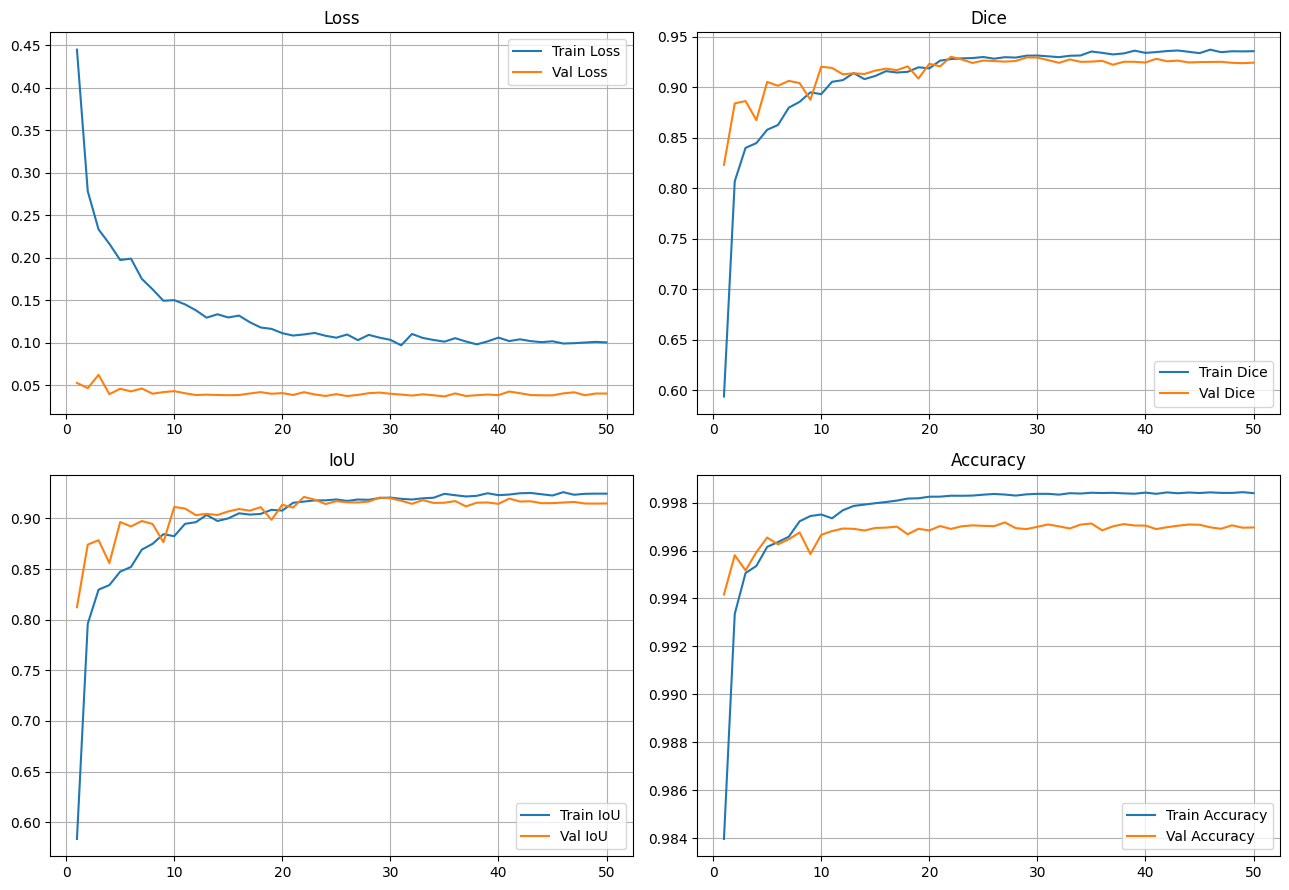

In [13]:
epochs = range(1, len(history['train_loss']) + 1)

fig, axes = plt.subplots(2, 2, figsize=(13, 9))

axes[0, 0].plot(epochs, history['train_loss'], label='Train Loss')
axes[0, 0].plot(epochs, history['val_loss'], label='Val Loss')
axes[0, 0].set_title('Loss')
axes[0, 0].legend()
axes[0, 0].grid(True)

axes[0, 1].plot(epochs, history['train_dice'], label='Train Dice')
axes[0, 1].plot(epochs, history['val_dice'], label='Val Dice')
axes[0, 1].set_title('Dice')
axes[0, 1].legend()
axes[0, 1].grid(True)

axes[1, 0].plot(epochs, history['train_iou'], label='Train IoU')
axes[1, 0].plot(epochs, history['val_iou'], label='Val IoU')
axes[1, 0].set_title('IoU')
axes[1, 0].legend()
axes[1, 0].grid(True)

axes[1, 1].plot(epochs, history['train_accuracy'], label='Train Accuracy')
axes[1, 1].plot(epochs, history['val_accuracy'], label='Val Accuracy')
axes[1, 1].set_title('Accuracy')
axes[1, 1].legend()
axes[1, 1].grid(True)

plt.tight_layout()
plt.show()

In [14]:
unet_model.load_state_dict(torch.load(UNET_WEIGHT_PATH, map_location=DEVICE))
unet_model.eval()

test_dice = test_iou = test_acc = 0.0
with torch.no_grad():
    for images, masks in test_loader:
        images, masks = images.to(DEVICE), masks.to(DEVICE)
        outputs = unet_model(images)
        preds = (torch.sigmoid(outputs) > 0.5).float()
        d, i, a = calculate_metrics_batch(preds, masks)
        test_dice += d
        test_iou += i
        test_acc += a

n_test = len(test_loader)
print('TEST SETI (egitim boyunca hic gorulmedi, model secimi icin kullanilmadi):')
print(f'Test Dice: {test_dice / n_test:.4f}')
print(f'Test IoU: {test_iou / n_test:.4f}')
print(f'Test Accuracy: {test_acc / n_test:.4f}')

TEST SETI (egitim boyunca hic gorulmedi, model secimi icin kullanilmadi):
Test Dice: 0.9362
Test IoU: 0.9280
Test Accuracy: 0.9979


In [15]:
def evaluate_unet_metrics(loader):
    unet_model.eval()
    all_metrics = {'dice': [], 'iou': [], 'accuracy': [], 'sensitivity': [], 'specificity': [], 'f1': []}
    hd95_values = []
    total_loss = 0.0
    with torch.no_grad():
        for images, masks in loader:
            images_d, masks_d = images.to(DEVICE), masks.to(DEVICE)
            outputs = unet_model(images_d)
            loss = loss_fn(outputs, masks_d)
            total_loss += loss.item()
            preds = (torch.sigmoid(outputs) > 0.5).float().cpu().numpy()
            gts = masks.cpu().numpy()
            for i in range(preds.shape[0]):
                pred_i = preds[i, 0].astype(np.uint8)
                gt_i = gts[i, 0].astype(np.uint8)
                m = segmentation_metrics(pred_i, gt_i)
                for k in all_metrics:
                    all_metrics[k].append(m[k])
                hd95_values.append(hd95_pixels(pred_i, gt_i))

    summary = {k: float(np.mean(v)) for k, v in all_metrics.items()}
    summary['loss'] = total_loss / len(loader)
    summary['hd95_pixel'] = float(np.nanmean(hd95_values)) if len(hd95_values) else float('nan')
    return summary


unet_val_summary = evaluate_unet_metrics(val_loader)
unet_test_summary = evaluate_unet_metrics(test_loader)

print('U-Net (Dogrulama):', unet_val_summary)
print('U-Net (Test):', unet_test_summary)

U-Net (Dogrulama): {'dice': 0.9303630759039625, 'iou': 0.9211905629158236, 'accuracy': 0.9969008290816944, 'sensitivity': 0.9421007303181558, 'specificity': 0.9982025775877807, 'f1': 0.9313864834469112, 'loss': 0.04161546454337419, 'hd95_pixel': 34.01973391335386}
U-Net (Test): {'dice': 0.9362483678323146, 'iou': 0.9279796489976523, 'accuracy': 0.9978868469682206, 'sensitivity': 0.9466042910688426, 'specificity': 0.9990731520932058, 'f1': 0.9368078687898661, 'loss': 0.03436667479201158, 'hd95_pixel': 25.573924117741228}


## 3. SAM2 ile Segmentasyon Sinir Iyilestirmesi

In [16]:
import sys
sys.path.insert(0, '/content/sam2')
from sam2.build_sam import build_sam2
from sam2.sam2_image_predictor import SAM2ImagePredictor

SAM2_CHECKPOINT = '/content/sam2/checkpoints/sam2.1_hiera_small.pt'
SAM2_CONFIG = 'configs/sam2.1/sam2.1_hiera_s.yaml'

sam2_model = build_sam2(config_file=SAM2_CONFIG, ckpt_path=SAM2_CHECKPOINT, device=DEVICE)
sam2_predictor = SAM2ImagePredictor(sam2_model)
print('SAM2 hazir.')

SAM2 hazir.


In [17]:
def clean_mask(mask, min_area=80):
    mask = (mask > 0).astype(np.uint8)
    labeled, num = ndimage.label(mask)
    out = np.zeros_like(mask, dtype=np.uint8)
    for i in range(1, num + 1):
        region = (labeled == i)
        if region.sum() >= min_area:
            out[region] = 1
    return out


def largest_component(mask):
    labeled, num = ndimage.label(mask)
    if num == 0:
        return mask.astype(np.uint8)
    sizes = ndimage.sum(mask, labeled, range(1, num + 1))
    largest = int(np.argmax(sizes)) + 1
    return (labeled == largest).astype(np.uint8)


def area_ratio(mask):
    return float(mask.sum() / mask.size)


def estimate_side(mask):
    if mask.sum() == 0:
        return 'belirgin degil'
    h, w = mask.shape
    left = mask[:, :w // 2].sum()
    right = mask[:, w // 2:].sum()
    if left > right * 1.2:
        return 'sol'
    elif right > left * 1.2:
        return 'sag'
    return 'orta/bilateral'


def estimate_extent(mask):
    r = area_ratio(mask)
    if r < 0.005:
        return 'cok kucuk'
    elif r < 0.02:
        return 'kucuk'
    elif r < 0.06:
        return 'orta'
    return 'genis'


def make_overlay(image_np, mask):
    overlay = image_np.copy()
    red = np.zeros_like(overlay)
    red[..., 0] = 255
    mask3 = np.stack([mask] * 3, axis=-1).astype(bool)
    overlay[mask3] = (0.65 * overlay[mask3] + 0.35 * red[mask3]).astype(np.uint8)
    return overlay


_infer_normalize = A.Compose([
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])


@torch.no_grad()
def unet_predict_external(image, patch_size=IMAGE_SIZE, stride=PATCH_STRIDE):
    # Model egitimi orijinal cozunurlukten kesilmis 224x224 parcalar uzerinde
    # yapildigi icin, disaridan gelen (herhangi boyutta) bir goruntuyu tek seferde
    # 224x224'e kucultup vermek egitim/cikarim uyumsuzluguna yol acar. Bunun yerine
    # ayni sekilde kaydirmali pencere (sliding window) ile 224x224 parcalara bolup
    # her parcayi ayri tahmin eder, sonra olasilik haritalarini birlestirir.
    image_np = np.array(image.convert('RGB'))
    h, w = image_np.shape[:2]

    if h <= patch_size:
        ys = [0]
    else:
        ys = sorted(set(list(range(0, h - patch_size, stride)) + [h - patch_size]))
    if w <= patch_size:
        xs = [0]
    else:
        xs = sorted(set(list(range(0, w - patch_size, stride)) + [w - patch_size]))

    prob_map = np.zeros((h, w), dtype=np.float32)
    count_map = np.zeros((h, w), dtype=np.float32)

    for y in ys:
        for x in xs:
            patch = image_np[y:y + patch_size, x:x + patch_size]
            ph, pw = patch.shape[:2]
            pad_h = patch_size - ph
            pad_w = patch_size - pw
            if pad_h > 0 or pad_w > 0:
                patch = cv2.copyMakeBorder(patch, 0, pad_h, 0, pad_w, cv2.BORDER_CONSTANT, value=0)

            tensor = _infer_normalize(image=patch)['image'].unsqueeze(0).to(DEVICE)
            output = unet_model(tensor)
            prob = torch.sigmoid(output)[0, 0].cpu().numpy()

            prob_map[y:y + ph, x:x + pw] += prob[:ph, :pw]
            count_map[y:y + ph, x:x + pw] += 1.0

    count_map[count_map == 0] = 1.0
    avg_prob = prob_map / count_map

    mask = (avg_prob > 0.5).astype(np.uint8)
    mask = clean_mask(mask)
    mask = largest_component(mask)
    confidence = float(avg_prob.max())
    return mask, confidence


@torch.no_grad()
def sam2_refine(image, unet_mask):
    image_np = np.array(image.convert('RGB'))
    sam2_predictor.set_image(image_np)
    h, w = image_np.shape[:2]
    if unet_mask.sum() > 0:
        ys, xs = np.where(unet_mask > 0)
        x1, x2 = xs.min(), xs.max()
        y1, y2 = ys.min(), ys.max()
        pad = 10
        x1 = max(0, x1 - pad)
        y1 = max(0, y1 - pad)
        x2 = min(w - 1, x2 + pad)
        y2 = min(h - 1, y2 + pad)
        box = np.array([x1, y1, x2, y2])
    else:
        box = np.array([int(w * 0.05), int(h * 0.05), int(w * 0.95), int(h * 0.95)])

    masks, scores, _ = sam2_predictor.predict(point_coords=None, point_labels=None, box=box, multimask_output=True)
    best = int(np.argmax(scores))
    sam_mask = masks[best].astype(np.uint8)
    sam_mask = clean_mask(sam_mask)
    sam_mask = largest_component(sam_mask)
    return sam_mask, float(scores[best])


def mask_iou(mask_a, mask_b):
    inter = np.logical_and(mask_a > 0, mask_b > 0).sum()
    union = np.logical_or(mask_a > 0, mask_b > 0).sum()
    if union == 0:
        return 0.0
    return float(inter) / float(union)


def combine_masks(unet_mask, sam_mask, min_agreement_iou=0.3):
    # U-Net bos maske (pnomotoraks yok) dedigi zaman sam2_refine'a kutu olarak
    # neredeyse tum goruntu verilir; bu durumda SAM2 pnomotoraksi degil, kutu
    # icindeki en "belirgin" nesneyi (goguz duvari, akciger siniri vb.) segmentleyip
    # buyuk bir yanlis pozitif alan uretebilir. Bu yuzden U-Net'in negatif karari
    # SAM2 lehine hicbir zaman gecersiz kilinmaz: U-Net bos maske uretirse IoU
    # kontrolune bakilmaksizin dogrudan bos maske donulur. (Eskiden bu durumda
    # SAM2 ciktisi hicbir kontrol yapilmadan dogrudan kullaniliyordu; bu, val/test
    # setinde specificity'yi ~0.53'e dusuren buyuk bir hataydi.)
    if unet_mask.sum() == 0:
        return np.zeros_like(sam_mask, dtype=np.uint8)

    agreement = mask_iou(unet_mask, sam_mask)
    if agreement < min_agreement_iou:
        return largest_component(clean_mask(unet_mask))

    combined = np.logical_or(unet_mask > 0, sam_mask > 0).astype(np.uint8)
    combined = clean_mask(combined)
    combined = largest_component(combined)
    return combined


def compute_reliability(unet_conf, sam_conf, final_mask):
    area_term = min(area_ratio(final_mask) / 0.03, 1.0)
    reliability = 0.35 * unet_conf + 0.45 * sam_conf + 0.20 * area_term
    return float(max(0.0, min(1.0, reliability)))

In [18]:
def evaluate_combined_metrics(dataset_samples, sample_size=None, seed=SEED):
    # SAM2'nin goruntu kodlayicisi (image encoder) her ornek icin ayri ayri
    # calistigi icin bu dongu yavastir. Buyuk val/test setlerinde tumunu
    # gezmek yerine sabit tohumlu rastgele bir orneklem kullanilir.
    samples = dataset_samples
    if sample_size is not None and len(samples) > sample_size:
        samples = random.Random(seed).sample(samples, sample_size)

    all_metrics = {'dice': [], 'iou': [], 'accuracy': [], 'sensitivity': [], 'specificity': [], 'f1': []}
    hd95_values = []
    for img_path, mask_path in samples:
        image = Image.open(img_path).convert('RGB')
        gt_mask = (np.array(Image.open(mask_path).convert('L')) > 0).astype(np.uint8)

        unet_mask, unet_conf = unet_predict_external(image)
        sam_mask, sam_conf = sam2_refine(image, unet_mask)
        final_mask = combine_masks(unet_mask, sam_mask)

        m = segmentation_metrics(final_mask, gt_mask)
        for k in all_metrics:
            all_metrics[k].append(m[k])
        hd95_values.append(hd95_pixels(final_mask, gt_mask))

    summary = {k: float(np.mean(v)) for k, v in all_metrics.items()}
    summary['hd95_pixel'] = float(np.nanmean(hd95_values)) if len(hd95_values) else float('nan')
    summary['n_samples'] = len(samples)
    return summary


sam2_val_summary = evaluate_combined_metrics(val_dataset.samples, sample_size=EVAL_SAMPLE_SIZE)
sam2_test_summary = evaluate_combined_metrics(test_dataset.samples, sample_size=EVAL_SAMPLE_SIZE)

print(f"SAM2 degerlendirme orneklem boyutu: val={sam2_val_summary['n_samples']}  test={sam2_test_summary['n_samples']}")

# Makaledeki Tablo 3 ile ayni satir/sutun duzeninde karsilastirma.
# HD95 burada piksel biriminde, makaledeki gibi mm degil (pixel spacing bilgisi yok).
# SAM2 satirlari EVAL_SAMPLE_SIZE kadar rastgele orneklem uzerinden hesaplanir (hiz icin).
# U-Net satiri SAM2 icermedigi icin hizlidir, tum val/test setinde hesaplanir.
comparison = pd.DataFrame({
    'U-Net (Dogrulama)': {
        'Loss': unet_val_summary['loss'],
        'Dice': unet_val_summary['dice'],
        'IoU': unet_val_summary['iou'],
        'Dogruluk': unet_val_summary['accuracy'],
        'Duyarlilik': unet_val_summary['sensitivity'],
        'Ozgulluk': unet_val_summary['specificity'],
        'F1': unet_val_summary['f1'],
        'HD95 (piksel)': unet_val_summary['hd95_pixel'],
    },
    'SAM2 (Dogrulama)': {
        'Loss': float('nan'),
        'Dice': sam2_val_summary['dice'],
        'IoU': sam2_val_summary['iou'],
        'Dogruluk': sam2_val_summary['accuracy'],
        'Duyarlilik': sam2_val_summary['sensitivity'],
        'Ozgulluk': sam2_val_summary['specificity'],
        'F1': sam2_val_summary['f1'],
        'HD95 (piksel)': sam2_val_summary['hd95_pixel'],
    },
    'SAM2 (Test)': {
        'Loss': float('nan'),
        'Dice': sam2_test_summary['dice'],
        'IoU': sam2_test_summary['iou'],
        'Dogruluk': sam2_test_summary['accuracy'],
        'Duyarlilik': sam2_test_summary['sensitivity'],
        'Ozgulluk': sam2_test_summary['specificity'],
        'F1': sam2_test_summary['f1'],
        'HD95 (piksel)': sam2_test_summary['hd95_pixel'],
    },
})

print('Tablo 3 tarzi karsilastirma (HD95 piksel biriminde, mm degil):')
comparison.round(4)

SAM2 degerlendirme orneklem boyutu: val=300  test=300
Tablo 3 tarzi karsilastirma (HD95 piksel biriminde, mm degil):


,U-Net (Dogrulama),SAM2 (Dogrulama),SAM2 (Test)
Loss,0.0416,NaN,NaN
Dice,0.9304,0.9128,0.9254
IoU,0.9212,0.9053,0.9142
Dogruluk,0.9969,0.9945,0.9977
Duyarlilik,0.9421,0.9378,0.9347
Ozgulluk,0.9982,0.9957,0.9987
F1,0.9314,0.9249,0.9254
HD95 (piksel),34.0197,55.3637,29.5545


## 4. VLM Tabanli Otomatik Raporlama (Qwen2-VL)

Sayisal alanlar (yerlesim, yayginlik, alan orani, guven skorlari) kural tabanli ve tekrarlanabilir sekilde hesaplanir. Degerlendirme, tedaviye yonelik karar destek ve sonuc bolumlerini iceren serbest metin ise acik kaynakli bir VLM tarafindan uretilir. Makalede belirtilen LLaVA-Med kurulumu ozel repo ve agirlik indirme gerektirdigi icin, ayni islevi goren ve Colab'da dogrudan yuklenebilen Qwen2-VL kullanilmistir; VLM_MODEL_ID degistirilerek LLaVA-Med agirliklarina gecilebilir.

**Bilinen kisitlama:** Qwen2-VL-2B-Instruct kucuk/genel amacli bir model oldugu icin, asagidaki ornek ciktilarda goruldugu gibi serbest metin bolumunde zaman zaman goruntude veya sayisal bulgularda karsiligi olmayan, konu disi tibbi terimler (orn. norolojik/kardiyak ifadeler) uretebiliyor (halusinasyon). Bu yuzden VLM'in urettigi serbest metin (Degerlendirme / Tedaviye Yonelik Karar Destek / Sonuc bolumleri) klinik olarak dogrulanmis kabul edilmemelidir; yalnizca kural tabanli sayisal bulgular (yerlesim, yayginlik, alan orani, guven skorlari) tekrarlanabilir ve guvenilirdir. Serbest metin, bir radyolog tarafindan goruntu ile karsilastirilarak dogrulanmadan klinik kararda kullanilmamalidir. Daha guvenilir serbest metin icin daha buyuk/alan-ozel bir VLM (orn. Qwen2-VL-7B veya LLaVA-Med) degerlendirilebilir.

In [19]:
from transformers import Qwen2VLForConditionalGeneration, AutoProcessor
from qwen_vl_utils import process_vision_info

VLM_MODEL_ID = 'Qwen/Qwen2-VL-2B-Instruct'

vlm_model = Qwen2VLForConditionalGeneration.from_pretrained(
    VLM_MODEL_ID, torch_dtype=torch.float16, device_map='auto'
)
vlm_processor = AutoProcessor.from_pretrained(VLM_MODEL_ID)
print('VLM hazir:', VLM_MODEL_ID)

config.json:   0%|          | 0.00/1.20k [00:00<?, ?B/s]

model.safetensors.index.json:   0%|          | 0.00/56.4k [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/729 [00:00<?, ?it/s]

...

tokenizer_config.json:   0%|          | 0.00/4.19k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

VLM hazir: Qwen/Qwen2-VL-2B-Instruct


In [20]:
def build_vlm_prompt(yerlesim, yayginlik, alan_orani, unet_guven, sam2_guven, guven_katsayisi):
    lines = []
    lines.append('Sen bir gogus radyolojisi karar destek asistanisin.')
    lines.append('Asagida bir akciger BT/PA goruntusu ve U-Net + SAM2 ile elde edilmis pnomotoraks segmentasyon bindirmesi verilmistir.')
    lines.append('Kirmizi isaretli bolge modelin pnomotoraks olarak isaretledigi alani gostermektedir.')
    lines.append('')
    lines.append('Sayisal bulgular:')
    lines.append(f'- Yerlesim: {yerlesim}')
    lines.append(f'- Yayginlik: {yayginlik}')
    lines.append(f'- Tahmini alan orani: {alan_orani}')
    lines.append(f'- U-Net guven skoru: {unet_guven}')
    lines.append(f'- SAM2 guven skoru: {sam2_guven}')
    lines.append(f'- Birlesik guvenilirlik katsayisi: {guven_katsayisi}')
    lines.append('')
    lines.append('Gorevin: bu bilgilere ve goruntuye dayanarak Turkce, tam cumlelerden olusan uc paragraf yazmak.')
    lines.append('Her paragraf, altinda gercek klinik yorum iceren en az 2-3 cumle olacak sekilde asagidaki basliklardan biriyle baslamalidir:')
    lines.append('1) Degerlendirme: goruntudeki bulgulari ve yukaridaki sayisal degerleri yorumla.')
    lines.append('2) Tedaviye Yonelik Karar Destek: guvenilirlik duzeyine gore olasi sonraki klinik adimlari oner.')
    lines.append('3) Sonuc: bulgularin kisa bir ozetini cikar.')
    lines.append('Onemli: sadece bu uc paragrafi yaz; bu talimat metnini, baslik aciklamalarini veya asagidaki cumleyi oldugu gibi tekrar etme. Bunun yerine kendi cumlelerinle, bu ciktinin kesin tani olmadigini ve bir karar destek ciktisi oldugunu dogal bir sekilde belirt.')
    return chr(10).join(lines)


@torch.no_grad()
def vlm_generate_report_text(overlay_image_pil, yerlesim, yayginlik, alan_orani, unet_guven, sam2_guven, guven_katsayisi):
    prompt_text = build_vlm_prompt(yerlesim, yayginlik, alan_orani, unet_guven, sam2_guven, guven_katsayisi)
    messages = [{
        'role': 'user',
        'content': [
            {'type': 'image', 'image': overlay_image_pil},
            {'type': 'text', 'text': prompt_text},
        ],
    }]
    chat_text = vlm_processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    image_inputs, video_inputs = process_vision_info(messages)
    inputs = vlm_processor(text=[chat_text], images=image_inputs, videos=video_inputs, padding=True, return_tensors='pt').to(DEVICE)

    # Onceki halinde (greedy decoding, do_sample=False) model prompttaki basliklari
    # ve talimat cumlesini oldugu gibi geri donduruyordu (gercek klinik icerik
    # uretmiyordu). Sampling + repetition_penalty bu kopyalama davranisini azaltir
    # ve modelin gercekten yeni metin uretmesini tesvik eder.
    generated_ids = vlm_model.generate(
        **inputs,
        max_new_tokens=400,
        do_sample=True,
        temperature=0.6,
        top_p=0.9,
        repetition_penalty=1.3,
    )
    generated_ids_trimmed = [out_ids[len(in_ids):] for in_ids, out_ids in zip(inputs.input_ids, generated_ids)]
    output_text = vlm_processor.batch_decode(generated_ids_trimmed, skip_special_tokens=True, clean_up_tokenization_spaces=False)[0]
    return output_text.strip()

In [21]:
def generate_report_vlm(image, final_mask, unet_conf, sam_conf):
    image_np = np.array(image.convert('RGB'))
    reliability = compute_reliability(unet_conf, sam_conf, final_mask)
    ratio = area_ratio(final_mask)

    if final_mask.sum() == 0 or ratio < 0.003:
        sonuc = 'Pnomotoraks lehine belirgin segmentasyon saptanmadi.'
        yer = 'belirgin degil'
        yay = 'yok'
    else:
        yer = estimate_side(final_mask)
        yay = estimate_extent(final_mask)
        if reliability >= 0.75:
            sonuc = 'Pnomotoraks ile uyumlu bulgu saptandi.'
        elif reliability >= 0.55:
            sonuc = 'Supheli pnomotoraks bulgusu saptandi.'
        else:
            sonuc = 'Dusuk guvenli supheli pnomotoraks segmentasyonu.'

    alan_orani = round(ratio, 6)
    unet_guven = round(float(unet_conf), 4)
    sam2_guven = round(float(sam_conf), 4)
    guven_katsayisi = round(float(reliability), 4)

    structured = {
        'sonuc': sonuc, 'yerlesim': yer, 'yayginlik': yay,
        'alan_orani': alan_orani, 'unet_guven': unet_guven,
        'sam2_guven': sam2_guven, 'guvenilirlik_katsayisi': guven_katsayisi,
    }

    overlay_img = make_overlay(image_np, final_mask)
    overlay_pil = Image.fromarray(overlay_img)
    vlm_free_text = vlm_generate_report_text(overlay_pil, yer, yay, alan_orani, unet_guven, sam2_guven, guven_katsayisi)

    report_lines = []
    report_lines.append('OTOMATIK RADYOLOJIK RAPOR')
    report_lines.append('')
    report_lines.append('1. Sayisal Bulgular (kural tabanli, tekrarlanabilir):')
    report_lines.append(f'Sonuc: {sonuc}')
    report_lines.append(f'Yerlesim: {yer}')
    report_lines.append(f'Yayginlik: {yay}')
    report_lines.append(f'Tahmini alan orani: {alan_orani}')
    report_lines.append(f'U-Net guven skoru: {unet_guven}')
    report_lines.append(f'SAM2 guven skoru: {sam2_guven}')
    report_lines.append(f'Birlesik guvenilirlik katsayisi: {guven_katsayisi}')
    report_lines.append('')
    report_lines.append(f'2. VLM Tabanli Klinik Yorum ({VLM_MODEL_ID}) - DENEYSEL, DOGRULANMAMIS:')
    report_lines.append(vlm_free_text)
    report_lines.append('')
    report_lines.append('3. Not:')
    report_lines.append('Bu cikti karar destek amaclidir, kesin tani yerine gecmez. Yukaridaki 2. bolumdeki VLM tabanli serbest metin zaman zaman goruntude veya sayisal bulgularda karsiligi olmayan ifadeler icerebilir (halusinasyon riski); bu yuzden yalnizca 1. bolumdeki kural tabanli sayisal bulgular tekrarlanabilir kabul edilmelidir. Serbest metin, bir radyolog tarafindan goruntu ile karsilastirilarak dogrulanmadan klinik kararda kullanilmamalidir.')

    report = chr(10).join(report_lines)
    return structured, overlay_img, report

In [ ]:
# Test setinden birkac ornek uzerinde nitel gosterim (VLM'yi butun test setinde calistirmak yavastir, bu yuzden ornek bazlidir)
import random as _random
sample_paths = _random.Random(SEED).sample(test_dataset.samples, min(3, len(test_dataset.samples)))

for img_path, mask_path in sample_paths:
    image = Image.open(img_path).convert('RGB')
    unet_mask, unet_conf = unet_predict_external(image)
    sam_mask, sam_conf = sam2_refine(image, unet_mask)
    final_mask = combine_masks(unet_mask, sam_mask)
    structured, overlay_img, report = generate_report_vlm(image, final_mask, unet_conf, sam_conf)

    plt.figure(figsize=(5, 5))
    plt.imshow(overlay_img)
    plt.title(os.path.basename(img_path))
    plt.axis('off')
    plt.show()
    print(report)
    print('=' * 80)

### VLM Rapor Kalitesi Degerlendirmesi (BLEU / ROUGE)

Bu olcumler, VLM'in urettigi serbest metnin bir radyoloğun yazdigi referans raporla ne kadar ortustugunu olcer. Calismasi icin radyologlarin gercekten yazdigi referans raporlari iceren bir CSV gerekir (`patient_id, filename, radyolog_raporu` sutunlari), o dosya olmadan bu olcum hesaplanamaz, uydurulamaz. Likert derecelendirmesi (klinik uygunluk) ve Cohen kappa (gozlemciler arasi uyum) ise doğrudan radyologlarin sistemi kullanip puanlamasini gerektirir, bunlar kodla otomatik uretilemez, ayri bir degerlendirme calismasi (anket/form) olarak yapilmalidir.

In [23]:
!pip install -q rouge-score nltk

REFERENCE_REPORTS_PATH = f'{PROCESSED_DIR}/reference_reports.csv'

if os.path.exists(REFERENCE_REPORTS_PATH):
    import nltk
    nltk.download('punkt', quiet=True)
    from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
    from rouge_score import rouge_scorer

    ref_df = pd.read_csv(REFERENCE_REPORTS_PATH)
    scorer = rouge_scorer.RougeScorer(['rouge1', 'rougeL'], use_stemmer=False)
    smoothing = SmoothingFunction().method1

    bleu_scores, rouge1_scores, rougeL_scores = [], [], []
    for _, row in ref_df.iterrows():
        img_path = os.path.join(PROCESSED_DIR, 'test', 'images', row['filename'])
        if not os.path.exists(img_path):
            continue
        image = Image.open(img_path).convert('RGB')
        unet_mask, unet_conf = unet_predict_external(image)
        sam_mask, sam_conf = sam2_refine(image, unet_mask)
        final_mask = combine_masks(unet_mask, sam_mask)
        _, _, generated_report = generate_report_vlm(image, final_mask, unet_conf, sam_conf)

        reference_text = str(row['radyolog_raporu'])
        bleu = sentence_bleu([reference_text.split()], generated_report.split(), smoothing_function=smoothing)
        rouge_result = scorer.score(reference_text, generated_report)

        bleu_scores.append(bleu)
        rouge1_scores.append(rouge_result['rouge1'].fmeasure)
        rougeL_scores.append(rouge_result['rougeL'].fmeasure)

    print(f'BLEU (ortalama): {np.mean(bleu_scores):.4f}')
    print(f'ROUGE-1 (ortalama): {np.mean(rouge1_scores):.4f}')
    print(f'ROUGE-L (ortalama): {np.mean(rougeL_scores):.4f}')
else:
    print(f'{REFERENCE_REPORTS_PATH} bulunamadi.')
    print('BLEU/ROUGE hesaplamak icin radyologlarin yazdigi referans raporlari iceren bir CSV gerekiyor (patient_id, filename, radyolog_raporu sutunlari).')
    print('Bu dosyayi olusturup ayni yola koyarsaniz bu hucre calisip skorlari hesaplar.')

  Preparing metadata (setup.py) ... done
/content/pnomotoraks_processed_v3_patches/reference_reports.csv bulunamadi.
BLEU/ROUGE hesaplamak icin radyologlarin yazdigi referans raporlari iceren bir CSV gerekiyor (patient_id, filename, radyolog_raporu sutunlari).
Bu dosyayi olusturup ayni yola koyarsaniz bu hucre calisip skorlari hesaplar.


## 5. (Istege Bagli) Gradio Demo Arayuzu

In [ ]:
import gradio as gr
import json as _json


def analyze_external_image(image):
    if image is None:
        blank = np.zeros((256, 256, 3), dtype=np.uint8)
        return blank, 'Goruntu yuklenmedi.', '{}', 'Lutfen bir goruntu yukleyin.'

    image = image.convert('RGB')
    try:
        unet_mask, unet_conf = unet_predict_external(image)
        sam_mask, sam_conf = sam2_refine(image, unet_mask)
        final_mask = combine_masks(unet_mask, sam_mask)
        structured, overlay_img, report = generate_report_vlm(image, final_mask, unet_conf, sam_conf)

        summary_lines = []
        summary_lines.append(f'Karar: {structured["sonuc"]}')
        summary_lines.append(f'Yerlesim: {structured["yerlesim"]}')
        summary_lines.append(f'Yayginlik: {structured["yayginlik"]}')
        summary_lines.append(f'U-Net guven: {structured["unet_guven"]}')
        summary_lines.append(f'SAM2 guven: {structured["sam2_guven"]}')
        summary_lines.append(f'Birlesik guvenilirlik: {structured["guvenilirlik_katsayisi"]}')
        summary = chr(10).join(summary_lines)

        return overlay_img, summary, _json.dumps(structured, ensure_ascii=False, indent=2), report
    except Exception as e:
        return np.array(image), f'Hata olustu: {str(e)}', '{}', 'Analiz tamamlanamadi.'


with gr.Blocks(title='SAM2 + U-Net + VLM Pnomotoraks Arayuzu') as demo:
    gr.Markdown('# SAM2 + U-Net + VLM Destekli Pnomotoraks Karar Destek Sistemi')
    gr.Markdown('Disaridan bir gogus BT/PA goruntusu yukleyin ve Analiz Et butonuna basin.')

    with gr.Row():
        with gr.Column():
            inp = gr.Image(type='pil', label='Disaridan Goruntu Yukle')
            btn = gr.Button('Analiz Et', variant='primary')
        with gr.Column():
            out_img = gr.Image(type='numpy', label='Segmentasyon Bindirmesi')

    with gr.Row():
        out_summary = gr.Textbox(label='Kisa Ozet', lines=8)
        out_json = gr.Textbox(label='Yapilandirilmis Cikti', lines=12)

    out_report = gr.Textbox(label='VLM Destekli Otomatik Radyoloji Raporu', lines=22)

    btn.click(fn=analyze_external_image, inputs=inp, outputs=[out_img, out_summary, out_json, out_report])

demo.launch(debug=True, share=True)

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://51c0147c81e426f205.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
